# Notebook 1 — How warm should a planet be?

### And how the Earth can have *two* answers at once

**What you will build:** a climate model. A real one — the same energy-balance
logic that sits at the heart of every model in the IPCC reports, just stripped
down to a single number for the whole planet.

**What you need to know going in:** nothing. Not Python, not meteorology.

**How to use this notebook.** Click on a grey box (a *cell*) and press
`Shift + Enter` to run it. Run the cells **in order, top to bottom** — later
cells use things defined earlier. If something breaks, go back to the top and
run everything again.

By the end you will have found something genuinely strange: with the *same*
amount of sunlight, the Earth has two stable temperatures — the one we live in,
and a frozen one. And getting out of the frozen one is much harder than falling
into it.

---

> **Setup.** This notebook needs only `numpy`, `scipy` and `matplotlib` — no
> data files, no downloads. If you have already run
> `00_observed_rainfall.ipynb`, use the same kernel and you are ready. If you
> have not set anything up yet, open that notebook and follow the
> *Before you start* section: Codespaces takes about five minutes and installs
> nothing on your laptop.

## 0. Setup

Every notebook starts by loading the tools it needs. `numpy` does arithmetic on
whole arrays of numbers at once; `matplotlib` draws. The rest of this cell just
makes the figures look consistent — you can ignore it for now.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- plotting style (set once, applies to every figure below) ---
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
C_YELLOW, C_MAGENTA, C_GREEN = "#eda100", "#e87ba4", "#008300"
C_VIOLET, C_RED = "#4a3aa7", "#e34948"
C_INK, C_MUTED, C_GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.figsize": (8, 4.6), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": C_INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "text.color": C_INK, "font.size": 10,
    "lines.linewidth": 2.0, "legend.frameon": False,
})

print("numpy version:", np.__version__)
print("Setup complete — you just ran your first cell.")

numpy version: 2.4.4
Setup complete — you just ran your first cell.


---
## 1. The simplest possible climate model

A planet sits in space. Sunlight comes in; infrared radiation goes out. If those
two are not equal, the planet warms or cools until they are. That is the whole
idea.

**Energy in.** The Sun delivers $S_0 \approx 1361\ \mathrm{W\,m^{-2}}$ to a
surface held face-on to the beam. The Earth intercepts that beam over its
*shadow*, a disc of area $\pi a^2$, but it *spreads* that energy over its whole
surface, a sphere of area $4\pi a^2$. So the globally averaged incoming flux is
$S_0/4 \approx 340\ \mathrm{W\,m^{-2}}$. A fraction $\alpha \approx 0.30$ (the
**albedo**) is reflected straight back by clouds, ice and bright deserts.

$$\text{ASR} = \frac{S_0}{4}\,(1-\alpha) \qquad \text{(Absorbed Solar Radiation)}$$

**Energy out.** Every object radiates. The Stefan–Boltzmann law says a perfect
emitter at temperature $T$ radiates

$$\text{OLR} = \sigma T^4 \qquad \text{(Outgoing Longwave Radiation)}$$

with $\sigma = 5.67\times10^{-8}\ \mathrm{W\,m^{-2}\,K^{-4}}$.

**Equilibrium** is where they balance. Set ASR = OLR and solve for $T$:

$$\boxed{\;T_e = \left[\frac{S_0(1-\alpha)}{4\sigma}\right]^{1/4}\;}$$

Notice the fourth root: to *double* the outgoing radiation you only need to warm
the planet by a factor $2^{1/4} \approx 1.19$. Radiation is a very stiff spring.
That is why the Earth's temperature is stable at all.

Let's compute $T_e$.

In [2]:
# Physical constants. In Python, `=` means "give this name to this value".
S0    = 1361.0      # solar constant, W m-2
alpha = 0.30        # planetary albedo, dimensionless (30% reflected)
sigma = 5.670e-8    # Stefan-Boltzmann constant, W m-2 K-4

ASR = S0 * (1 - alpha) / 4          # absorbed solar radiation, W m-2
T_e = (ASR / sigma) ** 0.25         # ** means "to the power of"

print(f"Absorbed solar radiation : {ASR:6.1f} W m-2")
print(f"Emission temperature     : {T_e:6.1f} K  =  {T_e - 273.15:5.1f} deg C")

Absorbed solar radiation :  238.2 W m-2
Emission temperature     :  254.6 K  =  -18.6 deg C


### 255 K is $-18\,^\circ$C.

That is the temperature of a planet with no greenhouse effect. The Earth's actual
surface averages about $288\ \mathrm{K} = 15\,^\circ$C. **We are 33 K warmer than
this calculation says we should be.** Something is missing.

---
## 2. The missing 33 K: a greenhouse in one line of algebra

Here is the crudest possible greenhouse. Put a single thin layer of atmosphere
above the surface. Make it **transparent to sunlight** (it is) and **opaque to
infrared** (it nearly is, thanks to water vapour and CO₂). The layer absorbs
everything the surface emits, and re-radiates it — half up to space, half back
down.

Write the budget for two surfaces. Let $T_s$ be the ground, $T_1$ the layer.

- **Top of atmosphere** (what space sees): $\ \sigma T_1^4 = \text{ASR}$
- **Ground:** $\ \sigma T_s^4 = \text{ASR} + \sigma T_1^4$

The ground receives sunlight *and* the downward glow of the layer. Substituting
the first into the second, $\sigma T_s^4 = 2\,\text{ASR}$, so

$$T_s = 2^{1/4}\,T_e.$$

With $n$ stacked opaque layers the same telescoping argument gives

$$\boxed{\;T_s = (n+1)^{1/4}\,T_e\;}$$

Let's see how many layers it takes to explain the Earth.

A **function** is a reusable recipe. You define it once with `def`, then call it
with different inputs. Here is our first one.

In [3]:
def surface_temp(n_layers, Te=T_e):
    """Surface temperature with n opaque atmospheric layers."""
    return (n_layers + 1) ** 0.25 * Te


for n in [0, 1, 2, 3]:
    Ts = surface_temp(n)
    print(f"{n} layers -> surface T = {Ts:6.1f} K ({Ts - 273.15:5.1f} deg C)")

print(f"\nEarth's observed surface temperature: 288.0 K ( 14.9 deg C)")

0 layers -> surface T =  254.6 K (-18.6 deg C)
1 layers -> surface T =  302.8 K ( 29.6 deg C)
2 layers -> surface T =  335.0 K ( 61.9 deg C)
3 layers -> surface T =  360.0 K ( 86.9 deg C)

Earth's observed surface temperature: 288.0 K ( 14.9 deg C)


One layer overshoots (303 K vs the observed 288 K) — the real atmosphere is not
perfectly opaque, it leaks. But the *magnitude* is right: one modest layer of
infrared-absorbing gas buys you roughly the 33 K we were missing. That is the
greenhouse effect, and you just derived it.

### Bookkeeping: one number instead of a layer

From here on we keep the greenhouse but stop drawing layers. Let the planet
radiate to space as a *leaky* emitter:

$$\text{OLR} = \varepsilon\,\sigma T_s^4, \qquad \varepsilon \approx 0.61.$$

$\varepsilon$ is the fraction of the surface's emission that actually escapes;
the rest is absorbed and returned by the atmosphere. Solving
$\varepsilon\sigma T_s^4 = \text{ASR}$ with $\alpha = 0.30$ gives $T_s = 288$ K —
the observed value, by construction. We have folded the entire greenhouse effect
into one tunable number. Crude, but it lets us move on.

> **Try it.** Change `alpha` to `0.6` in the cell in §1, re-run that cell and this
> one. What happens to the surface temperature? Hold that thought — it is the
> whole point of §4.

---
## 3. Stop solving, start plotting

So far we solved an equation by hand. Now we do something more powerful: plot
**energy in** and **energy out** as functions of temperature and *look* at where
they cross. This costs us the exact answer but buys us enormous insight — and it
keeps working when the algebra stops being solvable.

`np.linspace(a, b, n)` builds an array of `n` evenly spaced numbers from `a` to
`b`. Arithmetic on an array happens to every element at once — no loops needed.

Equilibrium surface temperature: 288.1 K = 14.9 deg C


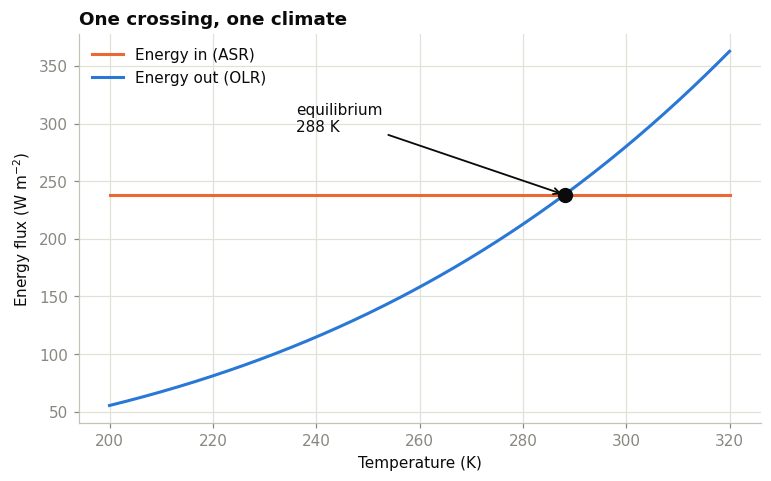

In [4]:
EPS = 0.61                           # atmospheric transmissivity (the greenhouse)

T = np.linspace(200, 320, 400)       # 400 candidate temperatures, in K

OLR_curve = EPS * sigma * T**4       # depends on T  -> a curve
ASR_curve = np.full_like(T, ASR)     # constant      -> a flat line

T_star = (ASR / (EPS * sigma)) ** 0.25
print(f"Equilibrium surface temperature: {T_star:.1f} K = {T_star - 273.15:.1f} deg C")

fig, ax = plt.subplots()
ax.plot(T, ASR_curve, color=C_ORANGE, label="Energy in (ASR)")
ax.plot(T, OLR_curve, color=C_BLUE,   label="Energy out (OLR)")
ax.plot(T_star, ASR, "o", ms=9, color=C_INK, zorder=5)
ax.annotate(f"equilibrium\n{T_star:.0f} K", xy=(T_star, ASR), xytext=(T_star - 52, ASR + 55),
            color=C_INK, arrowprops=dict(arrowstyle="->", color=C_INK, lw=1.2))
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_title("One crossing, one climate")
ax.legend(loc="upper left")
plt.show()

One crossing, so one possible climate. To the left of it, energy in exceeds
energy out and the planet warms — it slides right. To the right, it cools and
slides left. The crossing is an **attractor**: the climate is drawn back to it
from anywhere. This is why a planet has a well-defined temperature at all.

Now we break it.

---
## 4. Ice is white: the feedback that creates a second Earth

We held the albedo fixed at 0.30. But albedo *depends on temperature*: a cold
planet grows ice, ice is bright, bright reflects more sunlight, which makes it
colder still. This is the **ice–albedo feedback**, and it is positive — it
amplifies whatever nudge started it.

Model it with a smooth switch. The hyperbolic tangent, $\tanh$, runs smoothly
from $-1$ to $+1$ and is the standard way to write "soft threshold":

$$\alpha(T) = \frac{\alpha_i + \alpha_w}{2}
             \;-\; \frac{\alpha_i - \alpha_w}{2}\,\tanh\!\left(\frac{T - T_c}{\Delta T}\right)$$

- $\alpha_w = 0.25$ — ice-free ocean and land, dark
- $\alpha_i = 0.65$ — ice-covered, bright
- $T_c = 265$ K — the temperature around which ice takes over
- $\Delta T = 10$ K — how sharp the transition is

Check the limits yourself: as $T \to \infty$, $\tanh \to +1$ and
$\alpha \to \alpha_w$. As $T \to -\infty$, $\tanh \to -1$ and $\alpha \to \alpha_i$.
The midpoint $T = T_c$ gives the average of the two. Good.

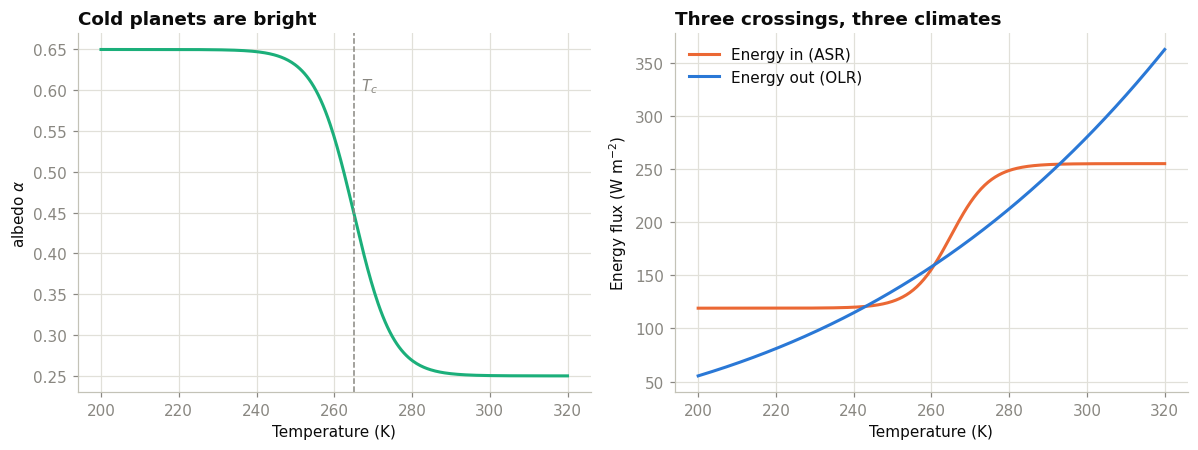

In [5]:
alpha_w, alpha_i = 0.25, 0.65        # ice-free and ice-covered albedo
T_c, dT = 265.0, 10.0                # threshold temperature and its width


def albedo(T):
    """Temperature-dependent planetary albedo."""
    return 0.5 * (alpha_i + alpha_w) - 0.5 * (alpha_i - alpha_w) * np.tanh((T - T_c) / dT)


def ASR_of_T(T, S=S0):
    """Absorbed solar radiation, now a function of temperature."""
    return S * (1 - albedo(T)) / 4


def OLR_of_T(T):
    """Outgoing longwave radiation from a leaky emitter."""
    return EPS * sigma * T**4


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.plot(T, albedo(T), color=C_AQUA)
ax1.axvline(T_c, color=C_MUTED, lw=1, ls="--")
ax1.set_xlabel("Temperature (K)"); ax1.set_ylabel(r"albedo $\alpha$")
ax1.set_title("Cold planets are bright")
ax1.text(T_c + 2, 0.60, "$T_c$", color=C_MUTED)

ax2.plot(T, ASR_of_T(T), color=C_ORANGE, label="Energy in (ASR)")
ax2.plot(T, OLR_of_T(T),  color=C_BLUE,   label="Energy out (OLR)")
ax2.set_xlabel("Temperature (K)"); ax2.set_ylabel("Energy flux (W m$^{-2}$)")
ax2.set_title("Three crossings, three climates")
ax2.legend(loc="upper left")
plt.tight_layout(); plt.show()

**Three crossings.** The curves now intersect three times. Three temperatures at
which the planet is in perfect energy balance — with *identical* sunlight.

Let's find them precisely. The trick: define $f(T) = \text{ASR} - \text{OLR}$, the
*net* energy gain. Equilibria are where $f(T) = 0$, which we find by looking for
places where `f` changes sign between neighbouring grid points, then refining
with a root finder.

In [6]:
from scipy.optimize import brentq


def net_flux(T, S=S0):
    """Net energy gained by the planet, W m-2. Zero at equilibrium."""
    return ASR_of_T(T, S) - OLR_of_T(T)


def find_equilibria(S=S0, Tmin=200, Tmax=330, n=2000):
    """Find every temperature where net_flux crosses zero."""
    grid = np.linspace(Tmin, Tmax, n)
    f = net_flux(grid, S)
    roots = []
    for i in range(len(grid) - 1):
        if f[i] * f[i + 1] < 0:                      # sign change -> a root in between
            roots.append(brentq(net_flux, grid[i], grid[i + 1], args=(S,)))
    return np.array(roots)


eq = find_equilibria()
print("Equilibrium temperatures (K):", np.round(eq, 2))

Equilibrium temperatures (K): [243.08 260.76 292.93]


### Which of these can the Earth actually sit in?

Not all equilibria are alike. Nudge the planet slightly off an equilibrium and
ask what happens next. Near a root $T^\*$, Taylor expand:

$$f(T) \approx f(T^\*) + f'(T^\*)\,(T - T^\*) = f'(T^\*)\,(T-T^\*),$$

and since the planet's temperature obeys $C\,\mathrm{d}T/\mathrm{d}t = f(T)$,
a small perturbation $T' = T - T^\*$ obeys

$$C\frac{\mathrm{d}T'}{\mathrm{d}t} = f'(T^\*)\,T'
  \qquad\Longrightarrow\qquad T'(t) = T'(0)\,e^{\,f'(T^\*)\,t/C}.$$

So the rule is simply:

$$f'(T^\*) < 0 \;\Rightarrow\; \textbf{stable} \qquad
  f'(T^\*) > 0 \;\Rightarrow\; \textbf{unstable}$$

A stable equilibrium damps perturbations exponentially; an unstable one grows
them. The unstable one is a **tipping point** — real, but impossible to sit on,
like a pencil balanced on its tip.

T* =  243.1 K   f'(T*) = -1.656 W m-2 K-1   -> stable
T* =  260.8 K   f'(T*) = +3.263 W m-2 K-1   -> unstable
T* =  292.9 K   f'(T*) = -3.376 W m-2 K-1   -> stable


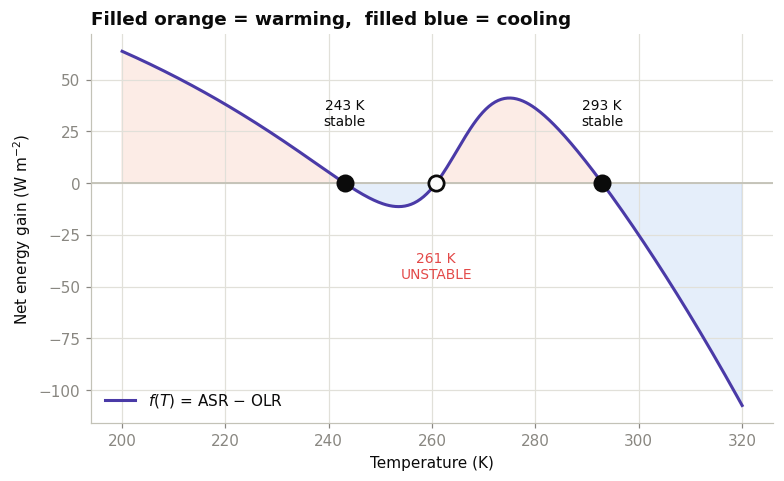

In [7]:
def dfdT(T, S=S0, h=0.01):
    """Numerical derivative of net_flux, by centred difference."""
    return (net_flux(T + h, S) - net_flux(T - h, S)) / (2 * h)


fig, ax = plt.subplots()
ax.plot(T, net_flux(T), color=C_VIOLET, label="$f(T)$ = ASR $-$ OLR")
ax.axhline(0, color="#c3c2b7", lw=1.2)
ax.fill_between(T, 0, net_flux(T), where=net_flux(T) > 0, color=C_ORANGE, alpha=0.12)
ax.fill_between(T, 0, net_flux(T), where=net_flux(T) < 0, color=C_BLUE,   alpha=0.12)

for Tstar in eq:
    slope = dfdT(Tstar)
    stable = slope < 0
    ax.plot(Tstar, 0, "o", ms=10, color=C_INK if stable else "#fcfcfb",
            mec=C_INK, mew=1.8, zorder=5)
    ax.annotate(f"{Tstar:.0f} K\n{'stable' if stable else 'UNSTABLE'}",
                xy=(Tstar, 0), xytext=(Tstar, 28 if stable else -46),
                ha="center", color=C_INK if stable else C_RED, fontsize=9)
    print(f"T* = {Tstar:6.1f} K   f'(T*) = {slope:+6.3f} W m-2 K-1   "
          f"-> {'stable' if stable else 'unstable'}")

ax.set_xlabel("Temperature (K)"); ax.set_ylabel("Net energy gain (W m$^{-2}$)")
ax.set_title("Filled orange = warming,  filled blue = cooling")
ax.legend(loc="lower left")
plt.show()

Read the shading as arrows: wherever the curve is above zero the planet is
gaining energy and slides **right**; below zero it slides **left**. The two solid
dots pull neighbours in. The open dot pushes them away.

The warm root near 293 K is *our* climate (a few degrees warm, because the
ice–albedo curve puts today's albedo slightly below 0.30 — fixable, and
Exercise 4 asks you to). The cold root near 243 K is **Snowball Earth**, a
completely ice-covered planet. The geological record says the Earth has actually
been there, twice, around 700 million years ago.

---
## 5. Watching it happen: integrating forward in time

Stability arguments tell us where the planet ends up. Let's *watch* it get there.

The planet has heat capacity. Warming a column of ocean of depth $H$ by one kelvin
takes $C = \rho\,c_w\,H$ joules per square metre:

$$C = 1000\ \tfrac{\mathrm{kg}}{\mathrm{m^3}} \times 4000\ \tfrac{\mathrm{J}}{\mathrm{kg\,K}} \times 100\ \mathrm{m}
    = 4\times10^{8}\ \mathrm{J\,m^{-2}\,K^{-1}}$$

and the temperature evolves by

$$C\,\frac{\mathrm{d}T}{\mathrm{d}t} = f(T).$$

We solve this the simplest way there is — the **forward Euler method**. Replace
the derivative by a finite difference over a short step $\Delta t$:

$$\frac{\mathrm{d}T}{\mathrm{d}t} \approx \frac{T^{n+1}-T^{n}}{\Delta t}
  \qquad\Longrightarrow\qquad
  \boxed{\;T^{n+1} = T^{n} + \frac{\Delta t}{C}\,f(T^{n})\;}$$

Start somewhere, take a small step in the direction the physics points, repeat.
Nearly every model in climate science is, underneath, this line repeated a very
large number of times.

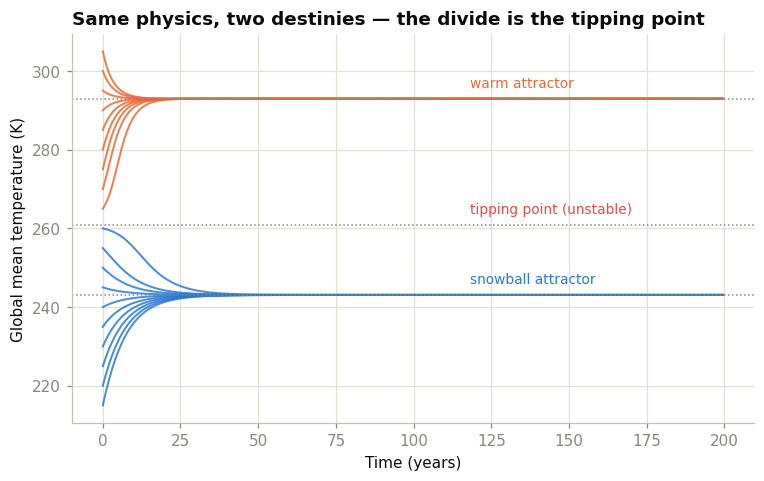

In [8]:
C_heat = 1000 * 4000 * 100.0         # J m-2 K-1  (100 m of ocean)
year = 365.25 * 24 * 3600            # seconds in a year
dt = 0.5 * year
n_steps = 400

starts = np.arange(215, 306, 5.0)    # many different initial temperatures

fig, ax = plt.subplots()
for T0 in starts:
    traj = np.empty(n_steps)
    Tn = T0
    for k in range(n_steps):         # <-- the Euler loop
        traj[k] = Tn
        Tn = Tn + dt / C_heat * net_flux(Tn)
    ends_warm = traj[-1] > 260
    ax.plot(np.arange(n_steps) * dt / year, traj,
            color=C_ORANGE if ends_warm else C_BLUE, lw=1.3, alpha=0.85)

for Tstar in eq:
    ax.axhline(Tstar, color=C_MUTED, ls=":", lw=1)
ax.text(118, eq[-1] + 3, "warm attractor", color=C_ORANGE, fontsize=9)
ax.text(118, eq[0] + 3,  "snowball attractor", color=C_BLUE, fontsize=9)
ax.text(118, eq[1] + 3,  "tipping point (unstable)", color=C_RED, fontsize=9)
ax.set_xlabel("Time (years)"); ax.set_ylabel("Global mean temperature (K)")
ax.set_title("Same physics, two destinies — the divide is the tipping point")
plt.show()

Every trajectory that starts above the tipping point ends up in our climate;
every one that starts below plunges into the snowball. The unstable equilibrium
is the watershed between two worlds.

---
## 6. Hysteresis: the climate remembers its past

Now the payoff. Slowly turn the Sun down, then slowly turn it back up, and track
the equilibrium the planet is actually sitting in.

The key word is **slowly**: at each step we let the planet settle, then change $S$
a little. The planet always ends up in whichever stable state is *nearest to where
it already was*. That single rule produces something remarkable.

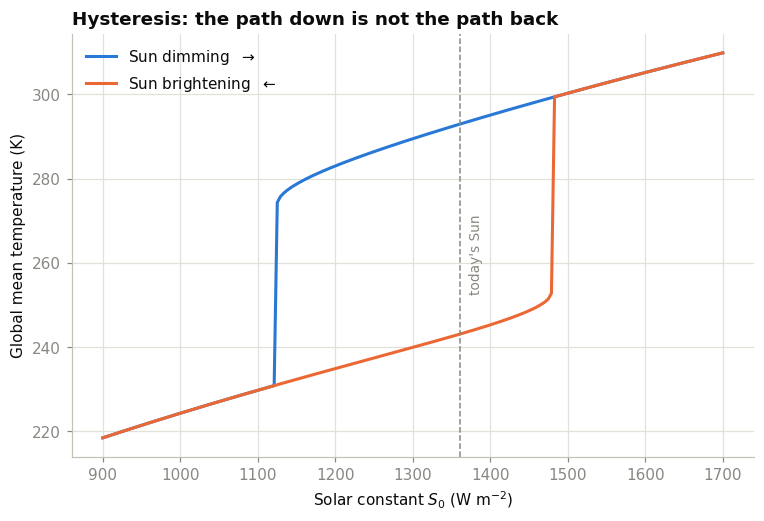

In [9]:
S_down = np.linspace(1700, 900, 200)       # dim the Sun
S_up   = np.linspace(900, 1700, 200)       # brighten it again


def settle(T0, S, n=1200, dt_=2 * year):
    """Relax to equilibrium starting from T0, with solar constant S."""
    Tn = T0
    for _ in range(n):
        Tn = Tn + dt_ / C_heat * net_flux(Tn, S)
    return Tn


T_track_down, Tn = [], 300.0
for S in S_down:
    Tn = settle(Tn, S); T_track_down.append(Tn)

T_track_up, Tn = [], Tn                     # continue from the frozen state
for S in S_up:
    Tn = settle(Tn, S); T_track_up.append(Tn)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(S_down, T_track_down, color=C_BLUE,   label="Sun dimming  $\\rightarrow$")
ax.plot(S_up,   T_track_up,   color=C_ORANGE, label="Sun brightening  $\\leftarrow$")
ax.axvline(S0, color=C_MUTED, ls="--", lw=1)
ax.text(S0 + 12, 262, "today's Sun", color=C_MUTED, fontsize=9, rotation=90, va="center")
ax.set_xlabel("Solar constant $S_0$ (W m$^{-2}$)")
ax.set_ylabel("Global mean temperature (K)")
ax.set_title("Hysteresis: the path down is not the path back")
ax.legend(loc="upper left")
plt.show()

### This is the figure to remember.

The two curves **do not lie on top of each other**. Dim the Sun and the climate
stays warm, stays warm, stays warm — then falls off a cliff into the snowball.
Brighten it back to exactly where it was and the planet *stays frozen*. You have
to overshoot by a long way before it jumps back out.

The system's state depends not just on the forcing but on **the history of the
forcing**. That is hysteresis, and it is why "we can just turn it back down
later" is a dangerous assumption about any part of the climate system with a
positive feedback in it — ice sheets, permafrost, the Atlantic overturning
circulation.

Also note the **width** of the loop. That width is a prediction of this model.
A more realistic model gives a different width. Comparing them is real research.

---
## 7. What you actually just did

You built a climate model from the Stefan–Boltzmann law, found that it has
multiple solutions, classified them by linear stability, integrated the governing
ODE forward in time, and discovered hysteresis. Along the way: variables,
functions, arrays, loops, root-finding, and six figures.

The Python you now know — `def`, `np.linspace`, array arithmetic, `for` loops,
`plt.plot` — is genuinely most of what you need for the rest of this project.

**What this model cannot do:** it has one temperature for the entire planet. No
equator, no poles, no seasons, no winds, no rain. Which means it cannot say
anything at all about the thing we are actually after — the band of thunderstorms
near the equator called the **ITCZ**, and why climate models get it so
spectacularly wrong.

Fixing that starts with one question: *where does the sunlight actually fall?*
That is Notebook 2.

---
## Exercises

Work these in new cells below. Struggling for a while before asking is the point.

**1. A dimmer young Sun.** The Sun was about 30% fainter 4 billion years ago
($S_0 \approx 950$). Run `find_equilibria(S=950)`. How many equilibria? What does
that say about how the early Earth stayed unfrozen — the *faint young Sun
paradox*? (Hint: what else could have been different? Try changing the greenhouse
by using `OLR = epsilon * sigma * T**4` with $\epsilon < 1$.)

**2. How sharp is the cliff?** Find the critical solar constant at which the warm
state disappears, to within 1 W m⁻². Do it by calling `find_equilibria` for many
values of `S` and detecting where the number of roots drops from 3 to 1.

**3. Feedback strength.** The parameter `dT` controls how abruptly ice takes over.
Make it large (`dT = 40`). Re-plot §4. Do the three equilibria survive? What does
that tell you about how *strong* a positive feedback has to be before it creates
multiple states?

**4. Sensitivity.** Define climate sensitivity as $\lambda = -1/f'(T^\*)$, the
warming per unit forcing at the warm equilibrium. Compute it with and without the
ice–albedo feedback (i.e. with `albedo` fixed at 0.30). By what factor does the
feedback amplify the response?

**5. Your own figure.** Remake the §6 hysteresis plot with the *unstable* branch
drawn in as a dashed line, so the full S-shaped curve is visible. (Hint:
`find_equilibria` returns all three roots — collect the middle one for each `S`
where three exist.)